In [38]:
import json
import sqlite3
import re
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import numpy as np

In [2]:
# Only works for some .json exported files from nsys-ui...
def process_json_report(filePath):
    kernel_trace = []
    kernel_names = []
    
    with open(filePath, 'r') as f:
        for line in f:
            try:
                entry = json.loads(line)
                if entry.get('type') == 79:
                    kernel_trace.append(line.get('CudaEvent'))
                    
                if entry.get('type') == 'String':
                     kernel_names.append(entry['value'])
            except json.JSONDecodeError as e:
                print(f"Skipping malformed line: {e}")
    return (kernel_trace, kernel_names)

In [2]:
# import sqlite3

# def process_sqlite_report(filePath):
        
#     con = sqlite3.connect(filePath)
#     con.row_factory = sqlite3.Row 
#     cur = con.cursor()
    
#     query = """
#     SELECT
#         names.value AS kernel_name,
#         k.start,
#         k.end,
#         k.end - k.start AS duration,
#         k.registersPerThread,
#         k.gridX, k.gridY, k.gridZ,
#         k.blockX, k.blockY, k.blockZ,
#         k.staticSharedMemory, k.dynamicSharedMemory, k.localMemoryPerThread, k.localMemoryTotal, k.sharedMemoryLimitConfig,
#         k.streamId,
#         k.deviceId
#     FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
#     JOIN StringIds AS names ON k.demangledName = names.id
#     ORDER BY k.start;
#     """
#     cur.execute(query)
    
#     rows = [dict(row) for row in cur.fetchall()]

#     return rows
    

In [3]:
# rows = process_sqlite_report("build/Linux-x86_64/report101_1575MHz_bindless_normal.sqlite")
# print(rows[0])
# print(rows[1])

{'kernel_name': 'Typeinfo name for popsift::normalizedSource::Horiz<(bool)0>', 'start': 313482745, 'end': 313878203, 'duration': 395458, 'registersPerThread': 28, 'gridX': 30, 'gridY': 2160, 'gridZ': 1, 'blockX': 128, 'blockY': 1, 'blockZ': 1, 'staticSharedMemory': 0, 'dynamicSharedMemory': 0, 'localMemoryPerThread': 0, 'localMemoryTotal': 42467328, 'sharedMemoryLimitConfig': 1, 'streamId': 39, 'deviceId': 0}
{'kernel_name': 'Typeinfo name for popsift::vert_kernel', 'start': 313885563, 'end': 314132477, 'duration': 246914, 'registersPerThread': 30, 'gridX': 60, 'gridY': 1080, 'gridZ': 1, 'blockX': 64, 'blockY': 2, 'blockZ': 1, 'staticSharedMemory': 0, 'dynamicSharedMemory': 0, 'localMemoryPerThread': 0, 'localMemoryTotal': 42467328, 'sharedMemoryLimitConfig': 1, 'streamId': 39, 'deviceId': 0}


In [5]:

    # UNION ALL

    # SELECT
    #     'runtime' AS activity_type,
    #     names.value AS name,
    #     r.start,
    #     r.end,
    #     r.end - r.start AS duration,
    #     NULL, NULL, NULL, NULL,
    #     NULL, NULL, NULL,
    #     NULL, NULL, NULL, NULL, NULL,
    #     NULL AS streamId,
    #     NULL AS deviceId,
    #     NULL AS bytes,
    #     NULL AS copyKind,
    #     NULL as srcKind,
    #     NULL as dstKind,
    #     NULL AS memKind
    # FROM CUPTI_ACTIVITY_KIND_RUNTIME AS r
    # JOIN StringIds AS names ON r.nameId = names.id

def process_sqlite_report_with_mem_and_call(filePath):
    con = sqlite3.connect(filePath)
    con.row_factory = sqlite3.Row 
    cur = con.cursor()

    query = """
    SELECT
        'kernel' AS activity_type,
        names.value AS name,
        k.start,
        k.end,
        k.end - k.start AS duration,
        k.registersPerThread,
        k.gridX, k.gridY, k.gridZ,
        k.blockX, k.blockY, k.blockZ,
        k.staticSharedMemory, k.dynamicSharedMemory,
        k.localMemoryPerThread, k.localMemoryTotal,
        k.sharedMemoryLimitConfig,
        k.streamId,
        k.deviceId,
        NULL AS bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        NULL AS memKind          -- new column for memset
    FROM CUPTI_ACTIVITY_KIND_KERNEL AS k
    JOIN StringIds AS names ON k.demangledName = names.id

    UNION ALL

    SELECT
        'memcpy' AS activity_type,
        '' AS name,
        m.start,
        m.end,
        m.end - m.start AS duration,
        NULL, NULL, NULL, NULL,
        NULL, NULL, NULL,
        NULL, NULL, NULL, NULL, NULL,
        m.streamId,
        m.deviceId,
        m.bytes,
        m.copyKind,
        m.srcKind,
        m.dstKind,
        NULL AS memKind
    FROM CUPTI_ACTIVITY_KIND_MEMCPY AS m


    UNION ALL

    SELECT
        'memset' AS activity_type,
        '' AS name,
        s.start,
        s.end,
        s.end - s.start AS duration,
        NULL, NULL, NULL, NULL,
        NULL, NULL, NULL,
        NULL, NULL, NULL, NULL, NULL,
        s.streamId,
        s.deviceId,
        s.bytes,
        NULL AS copyKind,
        NULL as srcKind,
        NULL as dstKind,
        s.memKind                  -- actual memKind value
    FROM CUPTI_ACTIVITY_KIND_MEMSET AS s

    ORDER BY start;
    """

    cur.execute(query)
    rows = [dict(row) for row in cur.fetchall()]
    return rows

In [6]:
import sqlite3
rows_m_c = process_sqlite_report_with_mem_and_call("build/Linux-x86_64/report101_1575MHz_bindless_normal.sqlite")

In [7]:
rows_m_c[9]

{'activity_type': 'memcpy',
 'name': '',
 'start': 310124805,
 'end': 310125221,
 'duration': 416,
 'registersPerThread': None,
 'gridX': None,
 'gridY': None,
 'gridZ': None,
 'blockX': None,
 'blockY': None,
 'blockZ': None,
 'staticSharedMemory': None,
 'dynamicSharedMemory': None,
 'localMemoryPerThread': None,
 'localMemoryTotal': None,
 'sharedMemoryLimitConfig': None,
 'streamId': 23,
 'deviceId': 0,
 'bytes': 48,
 'copyKind': 1,
 'srcKind': 0,
 'dstKind': 2,
 'memKind': None}

In [17]:
# for idx, row in enumerate(rows_m_c):
#     if idx < 150:
# #         print(row["activity_type"], row["start"], row["name"], row["copyKind"], idx)
# idx = 0
# found = 0
# while True:
#     if (rows_m_c[idx]["activity_type"] == "kernel"):
#         print(rows_m_c[idx], "idx - \n", idx)
#         found += 1
#         if found >= 2:
#             break

#     idx+=1

{'activity_type': 'kernel', 'name': 'Typeinfo name for popsift::normalizedSource::Horiz<(bool)0>', 'start': 313482745, 'end': 313878203, 'duration': 395458, 'registersPerThread': 28, 'gridX': 30, 'gridY': 2160, 'gridZ': 1, 'blockX': 128, 'blockY': 1, 'blockZ': 1, 'staticSharedMemory': 0, 'dynamicSharedMemory': 0, 'localMemoryPerThread': 0, 'localMemoryTotal': 42467328, 'sharedMemoryLimitConfig': 1, 'streamId': 39, 'deviceId': 0, 'bytes': None, 'copyKind': None, 'srcKind': None, 'dstKind': None, 'memKind': None} idx - 
 216
{'activity_type': 'kernel', 'name': 'Typeinfo name for popsift::vert_kernel', 'start': 313885563, 'end': 314132477, 'duration': 246914, 'registersPerThread': 30, 'gridX': 60, 'gridY': 1080, 'gridZ': 1, 'blockX': 64, 'blockY': 2, 'blockZ': 1, 'staticSharedMemory': 0, 'dynamicSharedMemory': 0, 'localMemoryPerThread': 0, 'localMemoryTotal': 42467328, 'sharedMemoryLimitConfig': 1, 'streamId': 39, 'deviceId': 0, 'bytes': None, 'copyKind': None, 'srcKind': None, 'dstKind':

In [9]:
rows[110]["kernel_name"]

'Typeinfo name for popsift::find_extrema_in_dog<(int)4, (int)1>'

In [8]:
import re
        # match = re.search(r'popsift::[a-zA-Z_][a-zA-Z_0-9]*(?:<[^>]+>)?', row["kernel_name"])
def clean_kernel_name(data):
    unique_names = []
    stufus = []
    it = 0
    for row in data:
        if row["activity_type"] != "kernel":
            continue
        match = re.search(r'Normalize|popsift::[a-zA-Z_][a-zA-Z_0-9]*', row["name"])
        match_template = re.search(r'Normalize|popsift::\w+(::\w+)*<[^>]+>$', row["name"])
        
        if match_template:
            if match_template.group() not in unique_names:
                unique_names.append(match_template.group())
            row["name"] = match_template.group() # Update with shorter name
        elif match:
            if match.group() not in unique_names:
                unique_names.append(match.group())
            row["name"] = match.group() # Update with shorter name

        else:
            print("Well shit ", row["name"])

    return unique_names

names = clean_kernel_name(rows_m_c)

In [22]:
names

['popsift::normalizedSource::Horiz<(bool)0>',
 'popsift::vert_kernel',
 'popsift::absoluteSource::Horiz<(bool)1, (bool)0>',
 'popsift::Downscale',
 'popsift::make_dog',
 'popsift::find_extrema_in_dog<(int)4, (int)1>',
 'popsift::ori_par_subgroup',
 'popsift::ori_prefix_sum_subgroup',
 'popsift::sub_group_desc_loop',
 'Normalize',
 'popsift::Prep_features']

In [ ]:
print(rows[110]["kernel_name"])

In [9]:
import pandas as pd

df = pd.read_csv("build/Linux-x86_64/metadata_report101_1575MHz_bindless_normal.csv")
print(df.iloc[0].loc['filename'])

0001.png


In [10]:
print(df.iloc[0])

filename            0001.png
feature_count          11450
descriptor_count       14878
Name: 0, dtype: object


In [11]:
def frame_time_kernel(data, k_names, warmup_frame_count):
    # They are in order of occurance 
    in_frame = False
    start_time = 0
    frame_times = []
    frame_count = 0
    first_pos = 0
    for idx, row in enumerate(data):
        if row["activity_type"] != "kernel":
            continue
        if not in_frame and (row["name"] == k_names[0] or row["name"] == k_names[2] ):
            start_time = row["start"]
            in_frame = True
            if frame_count == warmup_frame_count:
                first_pos = idx
            
        if in_frame and row["name"] == k_names[-1]:
            if frame_count >= warmup_frame_count:
                # First 10 frames are warmup frames (in my initial case)
                frame_times.append(row["end"] - start_time)
                in_frame = False
            else:
                in_frame = False
            frame_count += 1
            
            
            
    return frame_times, first_pos
    # print(data[0]["kernel_name"])     

In [12]:
def kernel_times(data, k_names, warmup_frame_count, first_real_idx):
    # The timer for the kernel (broad specter if it is in a higher octave vs lower)
    k_dict = {}
    prev_end = -5
    prev_k_name = ""
    for idx, row in enumerate(data):
        # if idx < first_real_idx or idx > first_real_idx + 10:
        if idx < first_real_idx:
            continue
        if row["activity_type"] != "kernel":
            continue
        
        k_name = row["name"]
        # Add self
        if k_name in k_dict:
            k_dict[k_name][0] += row["end"] - row["start"]
            k_dict[k_name][1] += 1; # Count
        else: 
            k_dict[k_name] = [row["end"] - row["start"], 1]
            k_dict[k_name + "_deadTime"] = [0, 0] # Don't know the time here

        # prev_k_name = data[idx - 1]["kernel_name"]
        # Add connection to from prev to current kernel data
        if k_name == prev_k_name:
            # same kernel
            if row["start"] > prev_end:
                k_dict[k_name + "_deadTime"][0] += row["start"] - prev_end
                k_dict[k_name + "_deadTime"][1] += 1
        else:
            # Different kernel
            # if prev_k_name == "popsift::Prep_features" and k_name == "popsift::normalizedSource::Horiz<(bool)0>":
            #     # Skip as it's transition from pre
            #     prev_end = row["end"]
            #     prev_k_name = row["kernel_name"]
            #     continue
            
            #  don't want time from warmup kernel transfer
            # don't want overlapping kernel lauces to subtract the time
            if prev_end != -5 and row["start"] > prev_end: 
                combo_name = prev_k_name + "_to_" + k_name
                if combo_name in k_dict:
                    k_dict[combo_name][0] += row["start"] - prev_end
                    k_dict[combo_name][1] += 1
                else:
                    # First time
                    k_dict[combo_name] = [row["start"] - prev_end, 1]

        prev_end = row["end"]
        prev_k_name = row["name"]

    return k_dict


     # k_name = row["kernel_name"]
        # if k_name in k_dict:
        #     k_dict[k_name][0] += row["end"] - row["start"]
        #     k_dict[k_name][1] += 1; # Count
        #     prev_k_name = data[idx - 1]["kernel_name"]
        #     if k_name == prev_k_name:
        #         # same kernel
        #         k_dict[k_name + "_deadTime"][0] += row["start"] - prev_end
        #         k_dict[k_name + "_deadTime"][1] += 1
        #     else:
        #         # Different kernel
        #         if prev_k_name == "popsift::Prep_features" and k_name == "popsift::normalizedSource::Horiz<(bool)0>":
        #             continue
                
        #         combo_name = prev_k_name + "_to_" + k_name
        #         if combo_name in k_dict:
        #             # Already have this one
        #             k_dict[combo_name][0] += row["start"] - prev_end
        #             k_dict[combo_name][1] += 1
        #         else:
        #             # add this one
        #             k_dict[combo_name] = [row["start"] - prev_end, 1]
                
        #     prev_end = row["end"]
        # else:
        #     k_dict[k_name] = [row["end"] - row["start"], 1]
        #     k_dict[k_name + "_deadTime"] = [0, 0] # Don't know the time here
        #     prev_end = row["end"]

In [13]:
times, first_real_row_idx = frame_time_kernel(rows_m_c, names, 10)

In [15]:
first_real_row_idx

1461

In [16]:
all_k_times = kernel_times(rows_m_c, names, 10, first_real_row_idx)
# pure_k_times = [x for xin k_times no]
k_times = {k: v for k, v in all_k_times.items() if '_to_' not in k and '_dead' not in k} # only pure kernel times
trans_times = {k: v for k, v in all_k_times.items() if '_to_' in k} # transition times (times k_to_next_k)
dead_times = {k: v for k, v in all_k_times.items() if '_dead' in k} # dead times (time between same kernel)

In [39]:
k_times

{'popsift::normalizedSource::Horiz<(bool)0>': [4743681495, 12000],
 'popsift::vert_kernel': [31874505776, 552000],
 'popsift::absoluteSource::Horiz<(bool)1, (bool)0>': [25676280124, 540000],
 'popsift::Downscale': [856584995, 96000],
 'popsift::make_dog': [11716599972, 108000],
 'popsift::find_extrema_in_dog<(int)4, (int)1>': [14309690695, 108000],
 'popsift::ori_par_subgroup': [8676890146, 92715],
 'popsift::ori_prefix_sum_subgroup': [784274517, 12000],
 'popsift::sub_group_desc_loop': [31506049921, 92715],
 'Normalize': [3953313866, 12000],
 'popsift::Prep_features': [75540437, 12000]}

In [18]:
def visualize_kernel_times(k_times, name_list):
    for idx, kernel in enumerate(k_times):
        if kernel[1] == 0:
            # Zero occurences
            print("Skipping")
        else:
            print(f"hello, {kernel[1]}")

In [19]:
visualize_kernel_times(k_times, [])

hello, o
hello, o
hello, o
hello, o
hello, o
hello, o
hello, o
hello, o
hello, o
hello, o
hello, o


In [20]:
import matplotlib.pyplot as plt
import numpy as np

def get_distinct_colors(n, cmap_name='tab10'):
    """
    Returns n distinct colours (RGBA) from a qualitative colormap or by sampling a continuous one.
    """
    # Try using discrete version if available
    try:
        cmap = plt.get_cmap(cmap_name, n)
        colors = cmap(range(n))
    except TypeError:
        # fallback: sample the continuous version
        cmap = plt.get_cmap(cmap_name)
        colors = cmap(np.linspace(0, 1, n))
    return colors

In [21]:
get_distinct_colors(20)

array([[0.12156863, 0.46666667, 0.70588235, 1.        ],
       [0.12156863, 0.46666667, 0.70588235, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [1.        , 0.49803922, 0.05490196, 1.        ],
       [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.17254902, 0.62745098, 0.17254902, 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ],
       [0.83921569, 0.15294118, 0.15686275, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.58039216, 0.40392157, 0.74117647, 1.        ],
       [0.54901961, 0.3372549 , 0.29411765, 1.        ],
       [0.54901961, 0.3372549 , 0.29411765, 1.        ],
       [0.89019608, 0.46666667, 0.76078431, 1.        ],
       [0.89019608, 0.46666667, 0.76078431, 1.        ],
       [0.49803922, 0.49803922, 0.49803922, 1.        ],
       [0.49803922, 0.49803922, 0.49803922, 1.        ],
       [0.7372549 , 0.74117647, 0.13333333, 1.        ],
       [0.7372549 , 0.74117647,

In [22]:
def visualize_kernel_bar(data):
    # compute averages
    avg_times = {}
    for k, (total, count) in data.items():
        if k == "popsift::Prep_features_to_popsift::normalizedSource::Horiz<(bool)0>":
            continue # skip time between frames
            
        if total > 0 and count > 0:  # skip zeros
            avg_times[k] = total / count / 1e6  # convert ns → ms
            print(f"name = {k} total {total}, count {count} -> average {total / count} -> in ms {total / count / 1000000}")
    
    # plot
    plt.figure(figsize=(12,6))
    plt.barh(list(avg_times.keys()), list(avg_times.values()))
    plt.xlabel("Average time per occurrence (ms)")
    plt.ylabel("Stage")
    plt.title("Per-Stage Average Processing Time")
    plt.tight_layout()
    plt.show()

In [23]:
def visualize_kernel_data_bar(data, colors):
    avg_times = {}
    for k, (total, count) in data.items():
        if k == "popsift::Prep_features_to_popsift::normalizedSource::Horiz<(bool)0>":
            continue # skip time between frames
            
        if total > 0 and count > 0:  # skip zeros
            avg_times[k] = total / count / 1e6  # convert ns → ms
            print(f"name = {k} total {total}, count {count} -> average {total / count} -> in ms {total / count / 1000000}")
    
    # plot
    plt.figure(figsize=(12,6))
    plt.barh(list(avg_times.keys()), list(avg_times.values()), color=colors)
    plt.xlabel("Average time per occurrence (ms)")
    plt.ylabel("Stage")
    plt.title("Per-Stage Average Processing Time")
    plt.tight_layout()
    plt.show()

In [24]:
# visualize_kernel_data_bar(k_times, colors)

name = popsift::normalizedSource::Horiz<(bool)0> total 4743681495, count 12000 -> average 395306.79125 -> in ms 0.39530679125
name = popsift::vert_kernel total 31874505776, count 552000 -> average 57743.66988405797 -> in ms 0.05774366988405797
name = popsift::absoluteSource::Horiz<(bool)1, (bool)0> total 25676280124, count 540000 -> average 47548.666896296294 -> in ms 0.0475486668962963
name = popsift::Downscale total 856584995, count 96000 -> average 8922.760364583333 -> in ms 0.008922760364583334
name = popsift::make_dog total 11716599972, count 108000 -> average 108487.03677777777 -> in ms 0.10848703677777777
name = popsift::find_extrema_in_dog<(int)4, (int)1> total 14309690695, count 108000 -> average 132497.1360648148 -> in ms 0.1324971360648148
name = popsift::ori_par_subgroup total 8676890146, count 92715 -> average 93586.69197001564 -> in ms 0.09358669197001564
name = popsift::ori_prefix_sum_subgroup total 784274517, count 12000 -> average 65356.20975 -> in ms 0.06535620975
nam

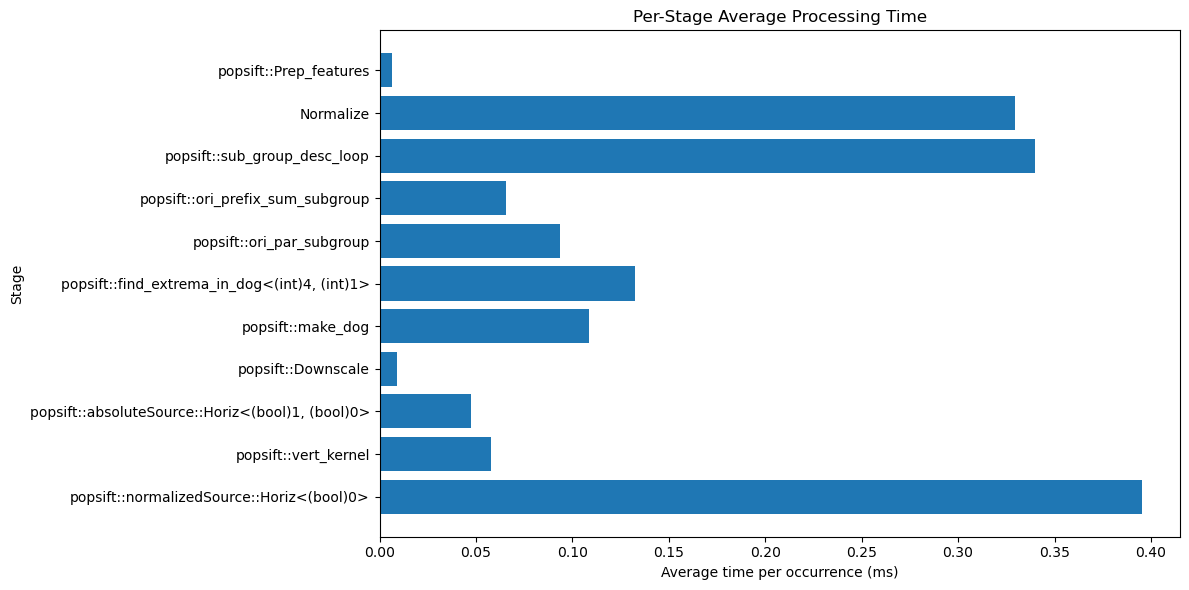

In [25]:
visualize_kernel_bar(k_times)

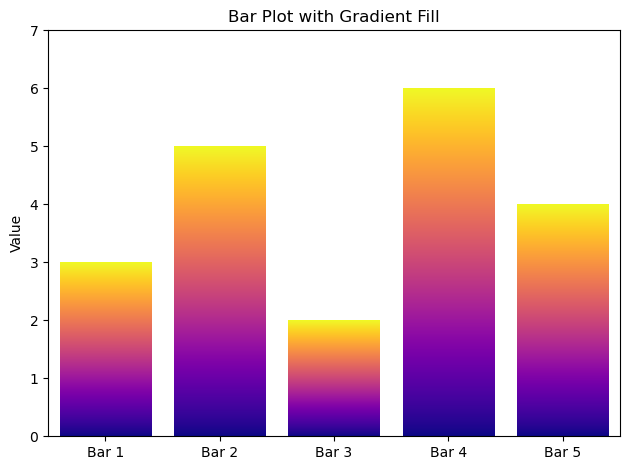

In [26]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import Rectangle
from matplotlib.transforms import Bbox

def gradient_rect(ax, xy, width, height, cmap='viridis', orientation='vertical'):
    """
    Draw a bar with a gradient fill.
    
    Parameters:
    - ax: matplotlib Axes object
    - xy: (x, y) position of bar
    - width: width of the bar
    - height: height of the bar
    - cmap: colormap for gradient
    - orientation: 'vertical' or 'horizontal'
    """
    # Create a gradient image
    if orientation == 'vertical':
        gradient = np.linspace(0, 1, 256).reshape(-1, 1)
    else:
        gradient = np.linspace(0, 1, 256).reshape(1, -1)
    
    # Display the gradient as an image clipped to the bar area
    im = ax.imshow(
        gradient,
        extent=(xy[0], xy[0]+width, xy[1], xy[1]+height),
        origin='lower',
        aspect='auto',
        cmap=cmap,
        clip_on=True
    )
    return im

# Sample data
x = np.arange(5)
y = np.array([3, 5, 2, 6, 4])

fig, ax = plt.subplots()

# Plot each bar with a gradient
for i in range(len(x)):
    gradient_rect(ax, (x[i] - 0.4, 0), 0.8, y[i], cmap='plasma')

# Set limits and labels
ax.set_xlim(-0.5, len(x) - 0.5)
ax.set_ylim(0, max(y) + 1)
ax.set_xticks(x)
ax.set_xticklabels([f'Bar {i+1}' for i in x])
ax.set_ylabel('Value')
ax.set_title('Bar Plot with Gradient Fill')

plt.tight_layout()
plt.show()


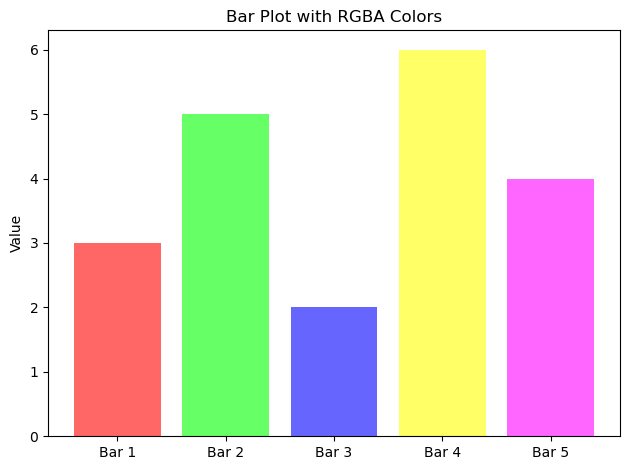

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Sample data
x = np.arange(5)
y = np.array([3, 5, 2, 6, 4])

# Define RGBA colors (values between 0 and 1)
colors = [
    (1.0, 0.0, 0.0, 0.6),  # semi-transparent red
    (0.0, 1.0, 0.0, 0.6),  # semi-transparent green
    (0.0, 0.0, 1.0, 0.6),  # semi-transparent blue
    (1.0, 1.0, 0.0, 0.6),  # semi-transparent yellow
    (1.0, 0.0, 1.0, 0.6),  # semi-transparent magenta
]

# Create the plot
fig, ax = plt.subplots()

# Plot bars with RGBA colors
bars = ax.bar(x, y, color=colors)

# Set labels and title
ax.set_xticks(x)
ax.set_xticklabels([f'Bar {i+1}' for i in x])
ax.set_ylabel('Value')
ax.set_title('Bar Plot with RGBA Colors')

plt.tight_layout()
plt.show()

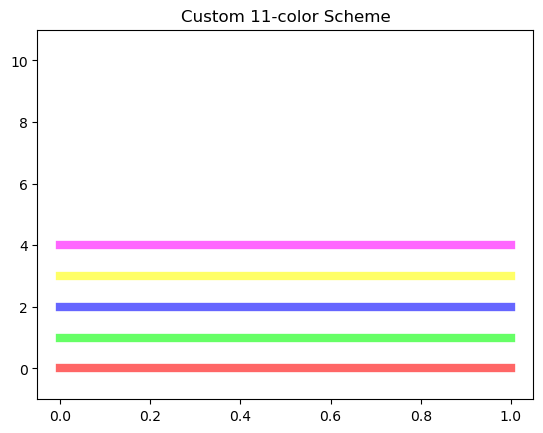

In [28]:
import matplotlib.pyplot as plt

for i, color in enumerate(colors):
    plt.plot([0, 1], [i, i], color=color, linewidth=6)
plt.ylim(-1, 11)
plt.title("Custom 11-color Scheme")
plt.show()

In [53]:
colors = [
    '#E24A33',  # strong red-orange
    '#348ABD',  # vivid blue
    '#988ED5',  # soft purple
    '#777777',  # gray
    '#FBC15E',  # warm yellow
    '#8EBA42',  # olive green
    '#FFB5B8',  # soft red-pink
    '#17BECF',  # cyan
    '#A1C9F4',  # light blue
    '#FF7F0E',  # orange
    '#2CA02C',  # green
]

# Generated by https://mokole.com/palette.html
colors_2 = [
    '#8b4513', # Saddleborwn
    '#006400', # darkgreen
    '#00008b', # darkblue
    '#ff0000',  #red
    '#ffd700',  # gold
    '#7fff00',  # chartreuse
    '#00ffff',   # aqua
    '#ff00ff',   # fuchisa
    '#6495ed', # cornflower
    '#ffe4b5',  # moccasin
    '#ff69b4'   #hotpink
]

def get_kernel_colors(colors, k_times):
    kernel_colors = {}
    it = 0
    for key in k_times.keys():
        kernel_colors[key] = colors[it]
        it += 1
    return kernel_colors

kernel_colors = get_kernel_colors(colors_2, k_times)

In [54]:
kernel_colors

{'popsift::normalizedSource::Horiz<(bool)0>': '#8b4513',
 'popsift::vert_kernel': '#006400',
 'popsift::absoluteSource::Horiz<(bool)1, (bool)0>': '#00008b',
 'popsift::Downscale': '#ff0000',
 'popsift::make_dog': '#ffd700',
 'popsift::find_extrema_in_dog<(int)4, (int)1>': '#7fff00',
 'popsift::ori_par_subgroup': '#00ffff',
 'popsift::ori_prefix_sum_subgroup': '#ff00ff',
 'popsift::sub_group_desc_loop': '#6495ed',
 'Normalize': '#ffe4b5',
 'popsift::Prep_features': '#ff69b4'}

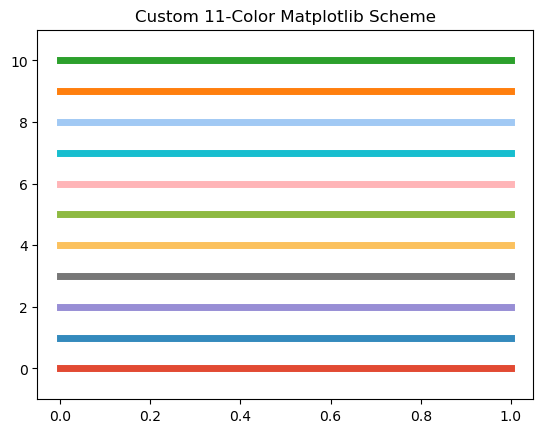

In [58]:
import matplotlib.pyplot as plt
import matplotlib as mpl

# Set the custom color cycle
mpl.rcParams['axes.prop_cycle'] = mpl.cycler(color=colors)

# Example plot
for i in range(11):
    plt.plot([0, 1], [i, i], linewidth=5)

plt.ylim(-1, 11)
plt.title("Custom 11-Color Matplotlib Scheme")
plt.show()

In [51]:
k_times

{'popsift::normalizedSource::Horiz<(bool)0>': [4743681495, 12000],
 'popsift::vert_kernel': [31874505776, 552000],
 'popsift::absoluteSource::Horiz<(bool)1, (bool)0>': [25676280124, 540000],
 'popsift::Downscale': [856584995, 96000],
 'popsift::make_dog': [11716599972, 108000],
 'popsift::find_extrema_in_dog<(int)4, (int)1>': [14309690695, 108000],
 'popsift::ori_par_subgroup': [8676890146, 92715],
 'popsift::ori_prefix_sum_subgroup': [784274517, 12000],
 'popsift::sub_group_desc_loop': [31506049921, 92715],
 'Normalize': [3953313866, 12000],
 'popsift::Prep_features': [75540437, 12000]}

In [52]:
kernel_colors

{'popsift::normalizedSource::Horiz<(bool)0>': '#E24A33',
 'popsift::vert_kernel': '#348ABD',
 'popsift::absoluteSource::Horiz<(bool)1, (bool)0>': '#988ED5',
 'popsift::Downscale': '#777777',
 'popsift::make_dog': '#FBC15E',
 'popsift::find_extrema_in_dog<(int)4, (int)1>': '#8EBA42',
 'popsift::ori_par_subgroup': '#FFB5B8',
 'popsift::ori_prefix_sum_subgroup': '#17BECF',
 'popsift::sub_group_desc_loop': '#A1C9F4',
 'Normalize': '#FF7F0E',
 'popsift::Prep_features': '#2CA02C'}

In [66]:
k_names_sub = {
    "popsift::normalizedSource::Horiz<(bool)0>": "Initial Horiz",
    'popsift::vert_kernel': "Vert_kernel",
    'popsift::absoluteSource::Horiz<(bool)1, (bool)0>': "Horiz",
    'popsift::Downscale': "Downscale",
    'popsift::make_dog': "Make_dog",
    'popsift::find_extrema_in_dog<(int)4, (int)1>': "Find_extrema",
    'popsift::ori_par_subgroup': "Ori_par",
    'popsift::ori_prefix_sum_subgroup': "Ori_prefix_sum",
    'popsift::sub_group_desc_loop': "Desc_loop",
    'Normalize': "Normalize",
    'popsift::Prep_features': "Prep_features",
}

In [114]:
def mean_kernel_bar(k_times, k_colors, k_names_sub):
    kernels = list(k_times.keys())
    times = [(k_times[k][0] / k_times[k][1])/1000000 for k in kernels]  # ns per call
    colors = [k_colors[k] for k in kernels]
    kernels = [k_names_sub[k] for k in k_times]
    # Plot
    plt.figure(figsize=(12, 6))
    bars = plt.bar(kernels, times, color=colors)
    plt.ylabel("Mean kernel runtime (ms)")
    plt.title("Kernel Execution Time per Call")
    # plt.xticks(rotation=-30)
    # plt.gca().invert_yaxis()  # So the fastest kernel is at the bottom
    plt.tight_layout()
    plt.show()

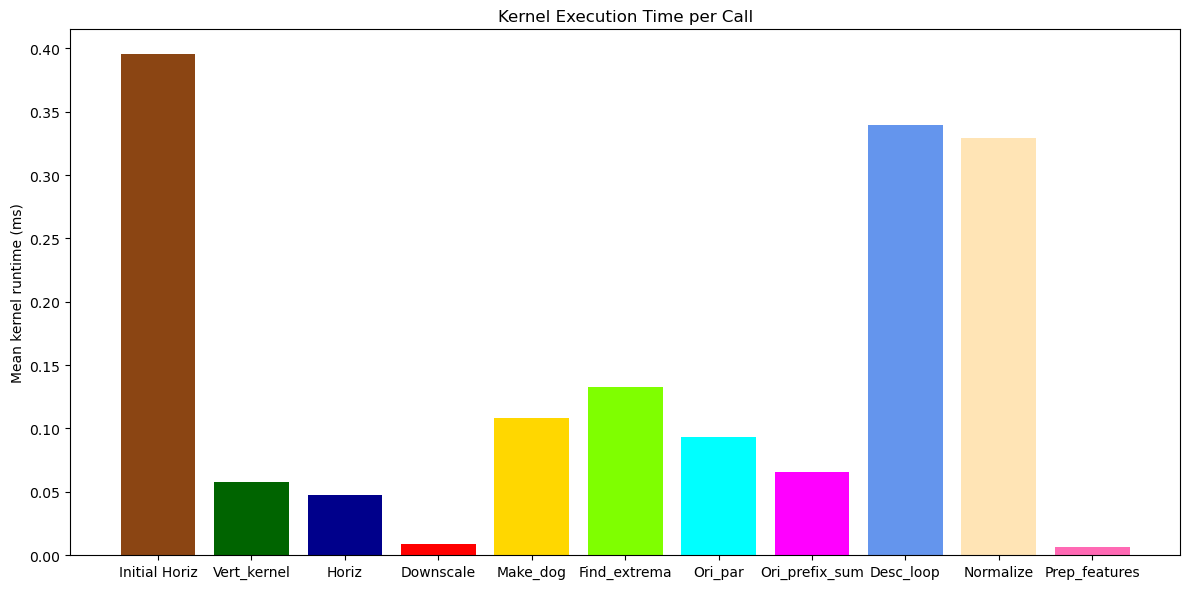

In [115]:
mean_kernel_bar(k_times, kernel_colors, k_names_sub)

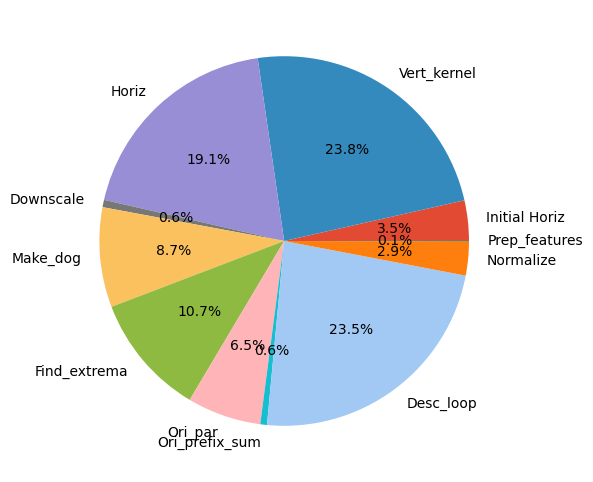

In [119]:
# Ugly AF
def kernel_runtime_contrib_pie(k_times, k_colors, k_names_sub):
    factor = 100 / sum([data[0] for data in k_times.values()])
    contrib = [factor * k_times[k][0] for k in k_times]
    colors = [k_colors[k] for k in k_times]
    kernels = [k_names_sub[k] for k in k_times]
    
    plt.figure(figsize=(20, 6))
    plt.pie(contrib, labels=kernels, autopct='%1.1f%%')

kernel_runtime_contrib_pie(k_times, kernel_colors, k_names_sub)    

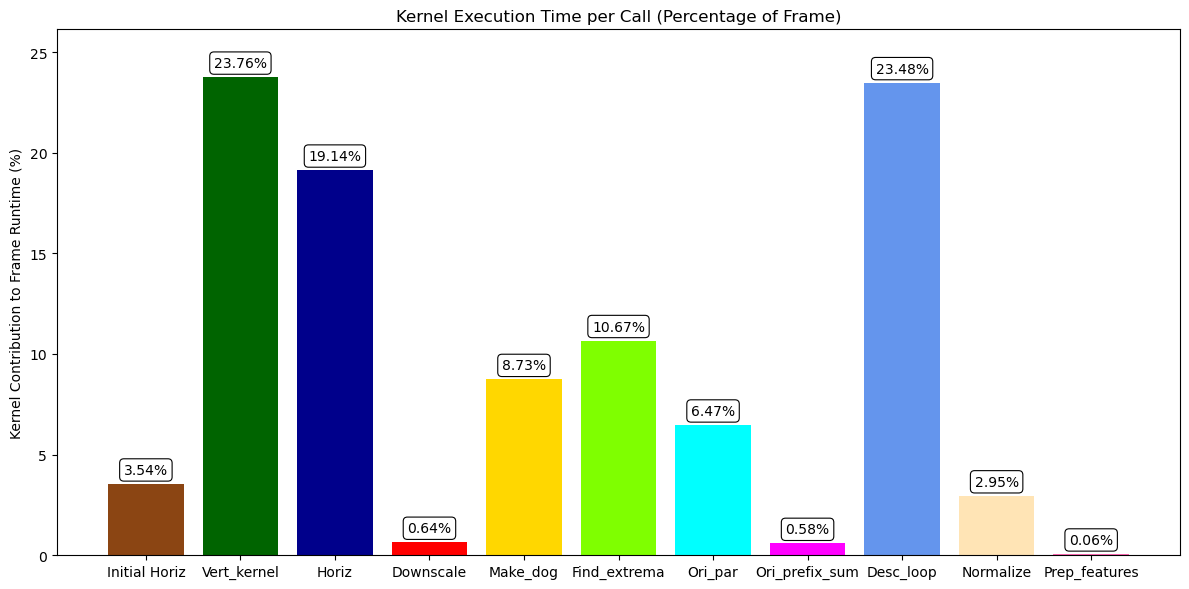

In [146]:
def kernel_runtime_contrib_bar(k_times, k_colors, k_names_sub):
    """Does not include the wait times between kernels only the actual kernel times for compute and takes perdentage of total"""

    # Should deal with overlapping kernels as they are counted doulbe when they don't actually do that much for the runtime...
    # Just because they are separate launches
    factor = 100 / sum([data[0] for data in k_times.values()])
    contrib = [factor * k_times[k][0] for k in k_times]
    colors = [k_colors[k] for k in k_times]
    kernels = [k_names_sub[k] for k in k_times]

    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(kernels, contrib, color=colors)

    for bar, value in zip(bars, contrib):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.35,
            f'{value:.2f}%',
            ha='center',
            va='bottom',
            fontsize=10,
            bbox=dict(
                boxstyle='round,pad=0.3',
                facecolor='white',
                edgecolor='black',
                linewidth=0.8
            )
        )

    ax.set_ylabel("Kernel Contribution to Frame Runtime (%)")
    ax.set_title("Total runtime contribution of kernels (only including time of kernels running)")
    ax.margins(y=0.1)  # Add padding above bars
    plt.tight_layout()
    plt.show()

kernel_runtime_contrib_bar(k_times, kernel_colors, k_names_sub)    

In [101]:
[k_times[k][0] for k in k_times]

[4743681495,
 31874505776,
 25676280124,
 856584995,
 11716599972,
 14309690695,
 8676890146,
 784274517,
 31506049921,
 3953313866,
 75540437]

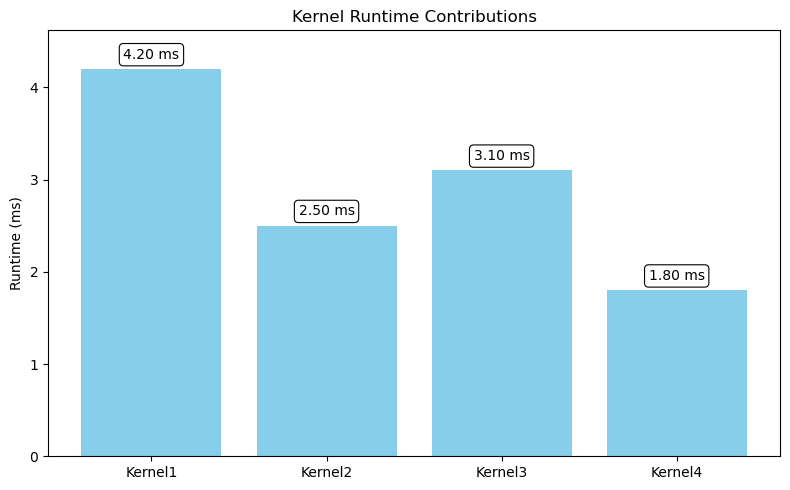